### Assignment 10: Pandas (Series, DataFrame, Functions, Filtering & Analysis)

- Problem Statement
You are working as a Data Analyst trainee. The company has provided sales and student performance data in tabular form and wants you to analyze it using Pandas.

- This assignment focuses ONLY on:
· Pandas Series
. Mathematical operations on Series
. Python functionalities on Series
. Creating and working with DataFrames
. Important DataFrame functions
· Filtering & basic analysis
. Simple plotting using Pandas (built-in plotting)

### Task 1: Pandas Series Basics
1. Import pandas as pd.
2. Create a Pandas Series from the list:
3. marks = [78, 85, 90, 66, 72]
4. Print:
o Series values
o Index
o Data type
5. Access:
o First element
o Last two elements

In [30]:
import pandas as pd
import logging

# Configured logger to display information
logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger()

# Initialized Python list and converted it to Series -> pd.Series() constructor
marks = [78,85,90,66,72]
series_simple = pd.Series(marks)

logger.info("----- Simple Series (default index) -------")
logger.info(series_simple)

# Series with labels -> makes data intuitive using arbitary string instead of position-> index parameter in pd.series()
indices = ['RN1', 'RN2', 'RN3', 'RN4', 'RN5']
series_labeled = pd.Series(data=marks, index=indices)

logger.info("\n----- Labeled Series (Explicit Index) ------")
logger.info(series_labeled)

# Python dictionary into a Series. map dictionary keys to Series index and values to data ,Passed dictionary to pd.Series()
sales_dict = {'Product A': 50, 'Product B': 85, 'Product C': 120}
series_dict = pd.Series(sales_dict)

logger.info("\n------ Series from Dictionary -------")
logger.info(series_dict)

# Accessed metadata like index, values, and data type -> used .index, .values, and .dtype
logger.info("\n------- Metadata Inspection ------")

logger.info(f"Index Labels: {series_simple.index}")
logger.info(f"Internal Data Type: {series_simple.dtype}")
logger.info(f"Underlying NumPy Array: {series_simple.values}")

logger.info(f"Index Labels: {series_labeled.index}")
logger.info(f"Internal Data Type: {series_labeled.dtype}")
logger.info(f"Underlying NumPy Array: {series_labeled.values}")

logger.info(f"Index Labels: {series_dict.index}")
logger.info(f"Internal Data Type: {series_dict.dtype}")
logger.info(f"Underlying NumPy Array: {series_dict.values}")

# Retrieve a specific element using its label ->demonstrated label-based selection for data extraction
first_element = series_labeled[0:]
target_val = series_labeled[-2:]
logger.info(f"\nFirst Element: {first_element}")
logger.info(f"\nValue for 'RN4', 'RN5': {target_val}")


----- Simple Series (default index) -------
0    78
1    85
2    90
3    66
4    72
dtype: int64

----- Labeled Series (Explicit Index) ------
RN1    78
RN2    85
RN3    90
RN4    66
RN5    72
dtype: int64

------ Series from Dictionary -------
Product A     50
Product B     85
Product C    120
dtype: int64

------- Metadata Inspection ------
Index Labels: RangeIndex(start=0, stop=5, step=1)
Internal Data Type: int64
Underlying NumPy Array: [78 85 90 66 72]
Index Labels: Index(['RN1', 'RN2', 'RN3', 'RN4', 'RN5'], dtype='str')
Internal Data Type: int64
Underlying NumPy Array: [78 85 90 66 72]
Index Labels: Index(['Product A', 'Product B', 'Product C'], dtype='str')
Internal Data Type: int64
Underlying NumPy Array: [ 50  85 120]

First Element: RN1    78
RN2    85
RN3    90
RN4    66
RN5    72
dtype: int64

Value for 'RN4', 'RN5': RN4    66
RN5    72
dtype: int64


### Task 2: Mathematical Operations on Series
- Using the marks Series:
1. Add 5 grace marks to all students.
2. Subtract 2 marks from all values.
3. Multiply all marks by 1.05.
4. Divide all marks by 2.
- Print results for each operation.

In [31]:
# Performed addition on the entire Series -> simulate a universal increase in scores (Broadcasting)
grace_marks = series_labeled + 5
logger.info("\n------ After Adding 5 Grace Marks -------")
logger.info(grace_marks)

# Performed subtraction on the original Series
deducted_marks = series_labeled - 2
logger.info("\n------ After Subtracting 2 Marks -------")
logger.info(deducted_marks)

# Applied a percentage-based increase (5% boost)
boosted_marks = series_labeled * 1.05
logger.info("\n------- After 5% Increase (Multiplication) ------")
logger.info(boosted_marks)

# Performed division on the Series
halved_marks = series_labeled / 2
logger.info("\n--- After Dividing by 2 ---")
logger.info(halved_marks)



------ After Adding 5 Grace Marks -------
RN1    83
RN2    90
RN3    95
RN4    71
RN5    77
dtype: int64

------ After Subtracting 2 Marks -------
RN1    76
RN2    83
RN3    88
RN4    64
RN5    70
dtype: int64

------- After 5% Increase (Multiplication) ------
RN1    81.90
RN2    89.25
RN3    94.50
RN4    69.30
RN5    75.60
dtype: float64

--- After Dividing by 2 ---
RN1    39.0
RN2    42.5
RN3    45.0
RN4    33.0
RN5    36.0
dtype: float64


### Task 3: Python Functionalities on Series
- Using the same Series:
1. Find:
o Maximum marks ,Minimum marks ,Sum of marks ,Mean marks
2. Apply a lambda function to check whether each student has passed (>= 70).
3. Count how many students passed.

In [32]:
# Calculated Maximum, Minimum, Sum, and Mean-> summarize performance of entire group
max_marks =series_labeled.max()
min_marks =series_labeled.min()
total_sum =series_labeled.sum()
avg_marks =series_labeled.mean()

logger.info(f"Maximum Marks: {max_marks}")
logger.info(f"Minimum Marks: {min_marks}")
logger.info(f"Sum of Marks: {total_sum}")
logger.info(f"Mean Marks: {avg_marks}")

# Created boolean mask identifying passing students -> categorize data points based on specific threshold (70) -> Used .apply() with a lambda function that evaluates each element 'x'
pass_status =series_labeled.apply(lambda x: x >= 70)
logger.info("\nPassing Status:")
logger.info(pass_status)

# Counted number of 'True' values in pass_status series
# Applied .sum() to boolean series; True values are treated as 1
pass_count = pass_status.sum()
logger.info(f"\nTotal Students Passed: {pass_count}")


Maximum Marks: 90
Minimum Marks: 66
Sum of Marks: 391
Mean Marks: 78.2

Passing Status:
RN1     True
RN2     True
RN3     True
RN4    False
RN5     True
dtype: bool

Total Students Passed: 4


### Task 4: Create a DataFrame
- Create a DataFrame students:
students = {
'Name': ['Amit', 'Neha', 'Rahul', 'Sneha', 'Pooja'],
'Marks': [78, 85, 90, 66, 72],
'Subject': ['Math', 'Math', 'Science', 'Science', 'Math']
}
1. Convert it into a DataFrame.
2. Print first 3 rows.
3. Print last 2 rows.
4. Print DataFrame shape and column names.

In [33]:
# Defined raw dictionary and converted to DataFrame
# To structure heterogeneous data (strings and integers) into a tabular format for analysis
students_dict = {
    'Name': ['Amit', 'Neha', 'Rahul', 'Sneha', 'Pooja'],
    'Marks': [78, 85, 90, 66, 72],
    'Subject': ['Math', 'Math', 'Science', 'Science', 'Math']
}

df_students = pd.DataFrame(students_dict)

# Displays beginning of dataset
# Uses .head(n) method where n=3
logger.info("------- First 3 Rows ------")
logger.info(df_students.head(3))

# checks for potential data corruption or trailing empty rows at end of a file
# Uses .tail(n) method where n=2
logger.info("\n------- Last 2 Rows -------")
logger.info(df_students.tail(2))

# To understand dataset size and label names for indexing
# Accesses .shape attribute for dimensions and .columns for header list
logger.info("\n------ DataFrame Metadata -------")
logger.info(f"DataFrame Shape (Rows, Columns): {df_students.shape}")
logger.info(f"Column Names: {list(df_students.columns)}")


------- First 3 Rows ------
    Name  Marks  Subject
0   Amit     78     Math
1   Neha     85     Math
2  Rahul     90  Science

------- Last 2 Rows -------
    Name  Marks  Subject
3  Sneha     66  Science
4  Pooja     72     Math

------ DataFrame Metadata -------
DataFrame Shape (Rows, Columns): (5, 3)
Column Names: ['Name', 'Marks', 'Subject']


### Task 5: Important DataFrame Functions
- Using the students DataFrame:
Use and print output of:
o .info(), 
o .describe(),
o .head(),
o .tail(),
- Sort students by Marks in descending order.
- Reset index after sorting.


In [34]:
import io

# basic information about DataFrame
# To check for null values and verify data types (Dtype)
# Uses .info(); since it prints to stdout, capture it in a buffer to log it
buf = io.StringIO()
df_students.info(buf=buf)
logger.info("------ DataFrame Info ------")
logger.info(buf.getvalue())

# Generates descriptive statistics
# To understand distribution, mean, and spread of numerical data
# Calls .describe() method on DataFrame
logger.info("\n------ Statistical Summary --------")
logger.info(df_students.describe())

# Views first and last 5 rows (default)
# Calls .head() and .tail()
logger.info("\n--- Head (First 5) --------")
logger.info(df_students.head())
logger.info("\n--- Tail (Last 5) ------")
logger.info(df_students.tail())

# Sorts DataFrame by 'Marks' in descending order
# Uses .sort_values() with 'ascending=False'
df_sorted = df_students.sort_values(by='Marks', ascending=False)

logger.info("\n------ Sorted by Marks (Descending) ------")
logger.info(df_sorted)

# Resets index to be sequential
# Uses .reset_index() with 'drop=True' to avoid keeping old index as a new column
df_final = df_sorted.reset_index(drop=True)

logger.info("\n------- Final DataFrame (Sorted & Index Reset) -------")
logger.info(df_final)


------ DataFrame Info ------
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Name     5 non-null      str  
 1   Marks    5 non-null      int64
 2   Subject  5 non-null      str  
dtypes: int64(1), str(2)
memory usage: 252.0 bytes


------ Statistical Summary --------
           Marks
count   5.000000
mean   78.200000
std     9.654015
min    66.000000
25%    72.000000
50%    78.000000
75%    85.000000
max    90.000000

--- Head (First 5) --------
    Name  Marks  Subject
0   Amit     78     Math
1   Neha     85     Math
2  Rahul     90  Science
3  Sneha     66  Science
4  Pooja     72     Math

--- Tail (Last 5) ------
    Name  Marks  Subject
0   Amit     78     Math
1   Neha     85     Math
2  Rahul     90  Science
3  Sneha     66  Science
4  Pooja     72     Math

------ Sorted by Marks (Descending) ------
    Name  Marks  Subject
2  Rahul     90  Science
1   Neha   

### Task 6: Filtering & Conditional Selection
- Perform the following filters:
1. Students who scored more than 75 marks.
2. Students belonging to subject Math.
3. Students who scored more than average marks.
4. Students who failed (marks < 70).

In [35]:
# Filters rows for marks greater than 75
# Applys a comparison operator directly to column 
high_scorers = df_students[df_students['Marks'] > 75]

logger.info("------ Students Scored > 75 ------")
logger.info(high_scorers)

# Filters rows based on a categorical string
# To isolate data specific to a particular domain or category for specialized analysis
math_students = df_students[df_students['Subject'] == 'Math']

logger.info("\n----- Math Subject Students ------")
logger.info(math_students)

# Filters rows, marks are strictly greater than calculated mean, (Relative Performance)
# Calculates mean() then filters 
avg_marks = df_students['Marks'].mean()
above_avg_students = df_students[df_students['Marks'] > avg_marks]

logger.info(f"\nAverage Marks: {avg_marks}")
logger.info("------- Students Above Average -------")
logger.info(above_avg_students)

# Filters rows, 'Marks' are below 70 
# Uses operator '<' to isolate scores below 70
failed_students = df_students[df_students['Marks'] < 70]

logger.info("\n------- Students Who Failed (< 70) -------")
logger.info(failed_students)


------ Students Scored > 75 ------
    Name  Marks  Subject
0   Amit     78     Math
1   Neha     85     Math
2  Rahul     90  Science

----- Math Subject Students ------
    Name  Marks Subject
0   Amit     78    Math
1   Neha     85    Math
4  Pooja     72    Math

Average Marks: 78.2
------- Students Above Average -------
    Name  Marks  Subject
1   Neha     85     Math
2  Rahul     90  Science

------- Students Who Failed (< 70) -------
    Name  Marks  Subject
3  Sneha     66  Science


### Task 7: Grouping & Basic Analysis
1. Find average marks per subject using groupby().
2. Count number of students per subject.
3. Find maximum marks per subject.

In [36]:
# Groups DataFrame by 'Subject' and calculate mean of 'Marks'
# Uses .groupby('Subject')['Marks'].mean()
avg_per_subject = df_students.groupby('Subject')['Marks'].mean()

logger.info("------ Average Marks per Subject -------")
logger.info(avg_per_subject)

# Groups by 'Subject' and count entries in 'Name' column ,-> checks popularity 
# Uses .groupby('Subject')['Name'].count()
count_per_subject = df_students.groupby('Subject')['Name'].count()

logger.info("\n------ Student Count per Subject -------")
logger.info(count_per_subject)

# Groups by 'Subject' and find highest value in 'Marks' 
# Uses .groupby('Subject')['Marks'].max()
max_per_subject = df_students.groupby('Subject')['Marks'].max()

logger.info("\n------ Maximum Marks per Subject ------")
logger.info(max_per_subject)

# To improve code readability (Single Pass over data) ->extra
# Uses .agg() method with a list of functions
summary_stats = df_students.groupby('Subject')['Marks'].agg(['mean', 'count', 'max'])

logger.info("\n--- Combined Summary Table ---")
logger.info(summary_stats)


------ Average Marks per Subject -------
Subject
Math       78.333333
Science    78.000000
Name: Marks, dtype: float64

------ Student Count per Subject -------
Subject
Math       3
Science    2
Name: Name, dtype: int64

------ Maximum Marks per Subject ------
Subject
Math       85
Science    90
Name: Marks, dtype: int64

--- Combined Summary Table ---
              mean  count  max
Subject                       
Math     78.333333      3   85
Science  78.000000      2   90


### Task 8: Pandas Plotting (Simple Graphs)
- Using Pandas built-in plotting:
1. Plot a bar graph of student names vs marks.
2. Plot a line graph of marks.
3. Plot a histogram of marks.

Generates Bar Graph: Student Names vs Marks


<Axes: title={'center': 'Marks by Student'}, xlabel='Name'>

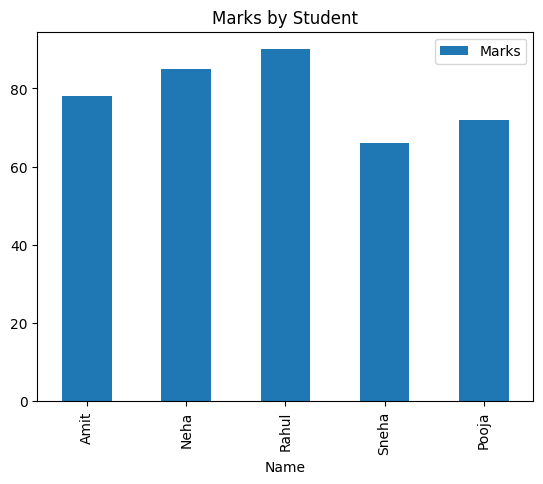

In [37]:
from IPython.display import display

# Create a bar chart showing marks for each student
# Sets 'Name' as index -> X-axis, then calls .plot(kind='bar')
logger.info("Generates Bar Graph: Student Names vs Marks")
bar_plot = df_students.plot(kind='bar', x='Name', y='Marks', title='Marks by Student')
display(bar_plot)


Generates Line Graph of Marks


Text(0, 0.5, 'Marks Obtained')

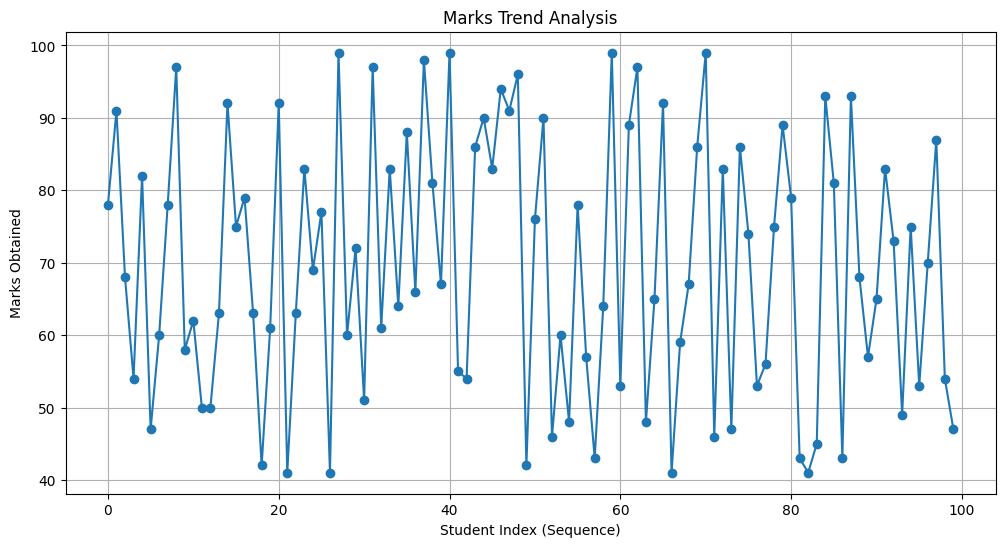

In [38]:
import numpy as np

# For data ingestion producing synthetic data -> more sensible line and histo plots
# Sets seed for pseudorandom number generator to ensure same numbers are generated every time
np.random.seed(42)

# creates dict containing 100 random marks from options of subjects
large_data = {
    'Marks': np.random.randint(40, 100, 100), #-> 100 random integers (40 [inclusive] and 100 [exclusive])
    'Subject': np.random.choice(['Math', 'Science'], 100)
}
# Converts dict to DataFrame
df_large = pd.DataFrame(large_data)

# Plots a line chart of 'Marks' Series
logger.info("Generates Line Graph of Marks")
line_plot = df_large['Marks'].plot(
    kind='line', 
    title='Marks Trend Analysis',
    figsize=(12,6), # changed layout -> ensure visibility of 100 points 
    marker='o',      # added dots to each data point -> clearer understanding
    grid=True #easier value estimation
)

# 3. Labeling using the plot object
line_plot.set_xlabel("Student Index (Sequence)")
line_plot.set_ylabel("Marks Obtained")

<Axes: title={'center': 'Marks Distribution (100 Students)'}, ylabel='Frequency'>

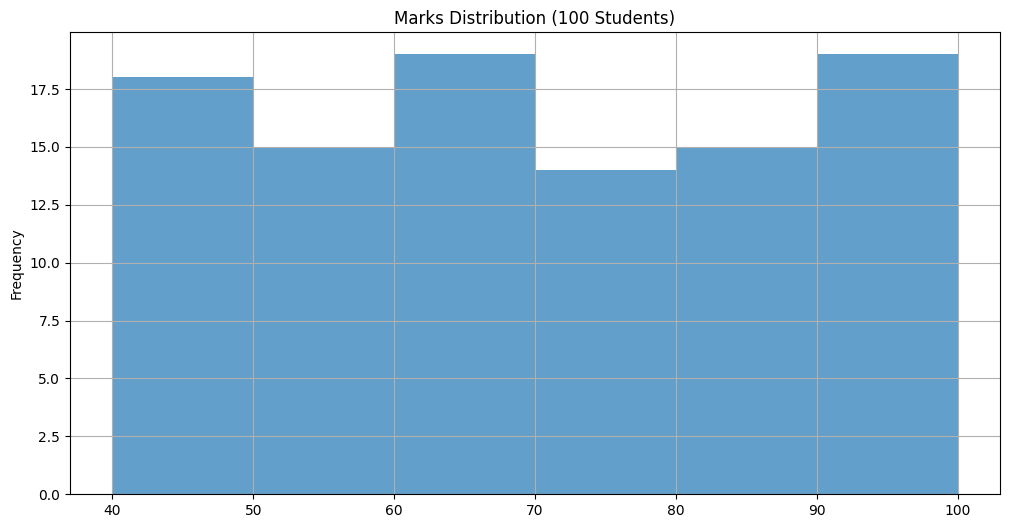

In [39]:
# Pandas Histogram with custom bins
df_large['Marks'].plot(
    kind='hist', 
    bins=[40, 50, 60, 70, 80, 90, 100], # Defines custom ranges for x-axis (e.g., 40-50, 50-60)
    title='Marks Distribution (100 Students)',
    figsize=(12, 6), 
    alpha=0.7, # Sets transparency to 70% (useful for seeing grid lines behind bars)
    grid=True
)


### Task 9: Mini Use Case: Sales Data Analysis
- Create a DataFrame:
sales = {
'Day': ['Mon', 'Tue', 'Wed', 'Thu', 'Fri'],
'Revenue': [1200, 1500, 900, 2000, 1800]
}
- Perform:
1. Total revenue
2. Average daily revenue
3. Day with highest revenue
4. Days where revenue > average
5. Plot revenue vs day

Total Revenue: INR 7400
Average Daily Revenue: INR 1480.0

Day with Highest Revenue: Thu (INR 2000)

Days with Above-Average Revenue:
   Day  Revenue
1  Tue     1500
3  Thu     2000
4  Fri     1800

Generates Sales Revenue Plot


<Axes: title={'center': 'Weekly Revenue Analysis'}, xlabel='Day'>

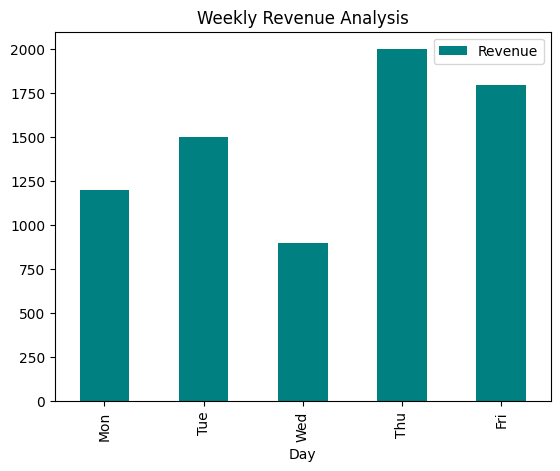

In [44]:
# Creates sales DataFrame and calculate total/average revenue
# Uses pd.DataFrame() followed by .sum() and .mean() methods
sales_dict = {
    'Day': ['Mon', 'Tue', 'Wed', 'Thu', 'Fri'],
    'Revenue': [1200, 1500, 900, 2000, 1800]
}
df_sales = pd.DataFrame(sales_dict)

total_revenue = df_sales['Revenue'].sum()
avg_revenue = df_sales['Revenue'].mean()

logger.info(f"Total Revenue: INR {total_revenue}")
logger.info(f"Average Daily Revenue: INR {avg_revenue}")

# Identifies specific day where revenue peaked
# Uses .idxmax() to find index of max value, then access 'Day' column at that index
max_idx = df_sales['Revenue'].idxmax()
best_day = df_sales.loc[max_idx, 'Day']
max_val = df_sales.loc[max_idx, 'Revenue']

logger.info(f"\nDay with Highest Revenue: {best_day} (INR {max_val})")

# Filters DataFrame for above-average performance
# Uses boolean indexing with 'avg_revenue' variable
above_avg_days = df_sales[df_sales['Revenue'] > avg_revenue]

logger.info("\nDays with Above-Average Revenue:")
logger.info(above_avg_days)

# Generates a bar chart of sales data
logger.info("\nGenerates Sales Revenue Plot")
sales_plot = df_sales.plot(kind='bar', x='Day', y='Revenue', title='Weekly Revenue Analysis', color='teal')
display(sales_plot)